In [1]:
# =============================================================
# PART 3: MODELING & EVALUASI - PREDIKSI STROKE
# Dataset: healthcare-dataset-stroke-data.csv
# Model: Random Forest + SMOTE (Handling Imbalanced Data)
# =============================================================

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, roc_auc_score, roc_curve)
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

In [3]:
# =============================================================
# LOAD & PREPROCESSING (sambungan dari Part 1 & 2)
# =============================================================

In [4]:
df = pd.read_csv('healthcare-dataset-stroke-data.csv')

In [5]:
# Handling Missing Values (BMI diisi dengan median)
df['bmi'] = df['bmi'].fillna(df['bmi'].median())

In [6]:
# Drop kolom ID (tidak relevan untuk prediksi)
df = df.drop(columns=['id'])


In [7]:
# Hapus baris dengan gender 'Other' (sangat sedikit, bisa ganggu model)
df = df[df['gender'] != 'Other']

In [8]:
# Label Encoding untuk fitur biner
le = LabelEncoder()
df['gender']         = le.fit_transform(df['gender'])         # Female=0, Male=1
df['ever_married']   = le.fit_transform(df['ever_married'])   # No=0, Yes=1
df['Residence_type'] = le.fit_transform(df['Residence_type']) # Rural=0, Urban=1

In [9]:
# One-Hot Encoding untuk fitur kategorikal nominal
df = pd.get_dummies(df, columns=['work_type', 'smoking_status'])

print("### Data Setelah Preprocessing ###")
print(f"Shape: {df.shape}")
print(df.head(3))

### Data Setelah Preprocessing ###
Shape: (5109, 18)
   gender   age  hypertension  heart_disease  ever_married  Residence_type  \
0       1  67.0             0              1             1               1   
1       0  61.0             0              0             1               0   
2       1  80.0             0              1             1               0   

   avg_glucose_level   bmi  stroke  work_type_Govt_job  \
0             228.69  36.6       1               False   
1             202.21  28.1       1               False   
2             105.92  32.5       1               False   

   work_type_Never_worked  work_type_Private  work_type_Self-employed  \
0                   False               True                    False   
1                   False              False                     True   
2                   False               True                    False   

   work_type_children  smoking_status_Unknown  smoking_status_formerly smoked  \
0               False      

In [10]:
# =============================================================
# BAGIAN 1: PEMISAHAN FITUR DAN TARGET
# =============================================================

X = df.drop(columns=['stroke'])
y = df['stroke']

print("\n### Distribusi Target ###")
print(y.value_counts())
print(f"Persentase Stroke    : {y.mean()*100:.2f}%")
print(f"Persentase Tdk Stroke: {(1-y.mean())*100:.2f}%")


### Distribusi Target ###
stroke
0    4860
1     249
Name: count, dtype: int64
Persentase Stroke    : 4.87%
Persentase Tdk Stroke: 95.13%


In [11]:
# =============================================================
# BAGIAN 2: TRAIN-TEST SPLIT (80:20)
# =============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y          # Penting! Menjaga proporsi kelas tetap seimbang
)

print(f"\n### Ukuran Data ###")
print(f"Data Training : {X_train.shape[0]} baris")
print(f"Data Testing  : {X_test.shape[0]} baris")
print(f"\nDistribusi target SEBELUM SMOTE (Training):\n{y_train.value_counts()}")



### Ukuran Data ###
Data Training : 4087 baris
Data Testing  : 1022 baris

Distribusi target SEBELUM SMOTE (Training):
stroke
0    3888
1     199
Name: count, dtype: int64


In [13]:
# =============================================================
# BAGIAN 3: HANDLING IMBALANCED DATA DENGAN SMOTE
# Catatan: SMOTE HANYA diterapkan pada data TRAINING!
# Jangan pernah SMOTE data testing → akan menyebabkan data leakage
# =============================================================

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f"\nDistribusi target SESUDAH SMOTE (Training):\n{y_train_res.value_counts()}")
print(f"Total data training setelah SMOTE: {len(X_train_res)} baris")


Distribusi target SESUDAH SMOTE (Training):
stroke
0    3888
1    3888
Name: count, dtype: int64
Total data training setelah SMOTE: 7776 baris


In [14]:
# =============================================================
# BAGIAN 4: TRAINING MODEL (RANDOM FOREST CLASSIFIER)
# =============================================================

print("\n" + "="*55)
print(" TRAINING RANDOM FOREST MODEL ".center(55, "="))
print("="*55)

model_rf = RandomForestClassifier(
    n_estimators=100,   # Jumlah pohon keputusan
    max_depth=None,     # Biarkan pohon tumbuh sepenuhnya
    random_state=42     # Untuk reproduksibilitas hasil
)
model_rf.fit(X_train_res, y_train_res)

print("Model berhasil dilatih!")



============= TRAINING RANDOM FOREST MODEL ============
Model berhasil dilatih!


In [15]:
# =============================================================
# BAGIAN 5: PREDIKSI DATA TESTING
# =============================================================

y_pred      = model_rf.predict(X_test)
y_pred_prob = model_rf.predict_proba(X_test)[:, 1]  # Probabilitas untuk ROC-AUC


In [16]:
# =============================================================
# BAGIAN 6: EVALUASI MODEL
# =============================================================

print("\n" + "="*55)
print(" HASIL EVALUASI MODEL ".center(55, "="))
print("="*55)

# A. Akurasi
akurasi = accuracy_score(y_test, y_pred)
print(f"\nA. Akurasi Model    : {akurasi * 100:.2f}%")

# B. ROC-AUC Score (lebih representatif untuk imbalanced data)
roc_auc = roc_auc_score(y_test, y_pred_prob)
print(f"   ROC-AUC Score    : {roc_auc:.4f}")

# C. Classification Report
print("\nB. Classification Report:")
print(classification_report(y_test, y_pred,
                            target_names=['Tidak Stroke (0)', 'Stroke (1)']))


================= HASIL EVALUASI MODEL ================

A. Akurasi Model    : 93.25%
   ROC-AUC Score    : 0.7762

B. Classification Report:
                  precision    recall  f1-score   support

Tidak Stroke (0)       0.95      0.98      0.97       972
      Stroke (1)       0.05      0.02      0.03        50

        accuracy                           0.93      1022
       macro avg       0.50      0.50      0.50      1022
    weighted avg       0.91      0.93      0.92      1022



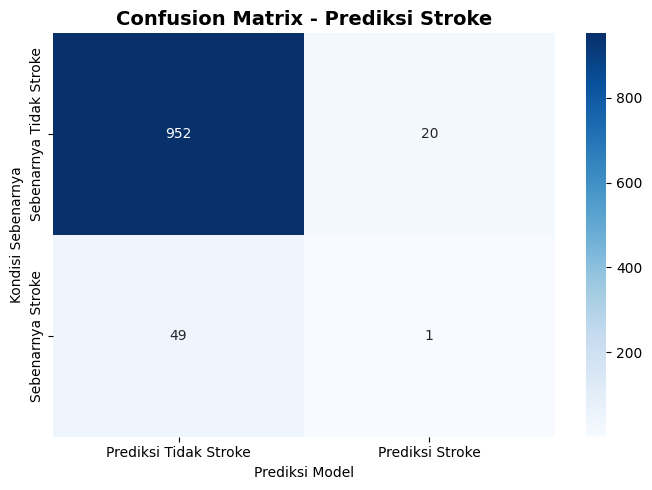

In [17]:
# =============================================================
# VISUALISASI 1: CONFUSION MATRIX
# =============================================================

plt.figure(figsize=(7, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Prediksi Tidak Stroke', 'Prediksi Stroke'],
            yticklabels=['Sebenarnya Tidak Stroke', 'Sebenarnya Stroke'])
plt.title('Confusion Matrix - Prediksi Stroke', fontsize=14, fontweight='bold')
plt.ylabel('Kondisi Sebenarnya')
plt.xlabel('Prediksi Model')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

In [18]:
# Interpretasi Confusion Matrix
TN, FP, FN, TP = cm.ravel()
print("\nC. Interpretasi Confusion Matrix:")
print(f"   True Negative  (TN): {TN}  → Diprediksi Tidak Stroke, Benar Tidak Stroke")
print(f"   False Positive (FP): {FP}  → Diprediksi Stroke, Ternyata Tidak Stroke")
print(f"   False Negative (FN): {FN}   → Diprediksi Tidak Stroke, Ternyata Stroke ⚠️")
print(f"   True Positive  (TP): {TP}   → Diprediksi Stroke, Benar Stroke ✓")
print(f"\n   ⚠ False Negative ({FN}) paling kritis di kasus medis!")
print(f"     Artinya: {FN} pasien stroke TIDAK terdeteksi oleh model.")


C. Interpretasi Confusion Matrix:
   True Negative  (TN): 952  → Diprediksi Tidak Stroke, Benar Tidak Stroke
   False Positive (FP): 20  → Diprediksi Stroke, Ternyata Tidak Stroke
   False Negative (FN): 49   → Diprediksi Tidak Stroke, Ternyata Stroke ⚠️
   True Positive  (TP): 1   → Diprediksi Stroke, Benar Stroke ✓

   ⚠ False Negative (49) paling kritis di kasus medis!
     Artinya: 49 pasien stroke TIDAK terdeteksi oleh model.


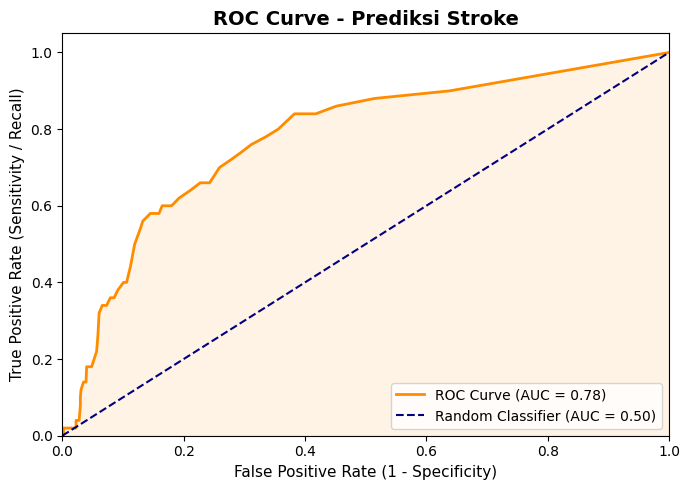

In [19]:
# =============================================================
# VISUALISASI 2: ROC CURVE
# =============================================================

fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2,
         label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--',
         label='Random Classifier (AUC = 0.50)')
plt.fill_between(fpr, tpr, alpha=0.1, color='darkorange')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=11)
plt.ylabel('True Positive Rate (Sensitivity / Recall)', fontsize=11)
plt.title('ROC Curve - Prediksi Stroke', fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150)
plt.show()

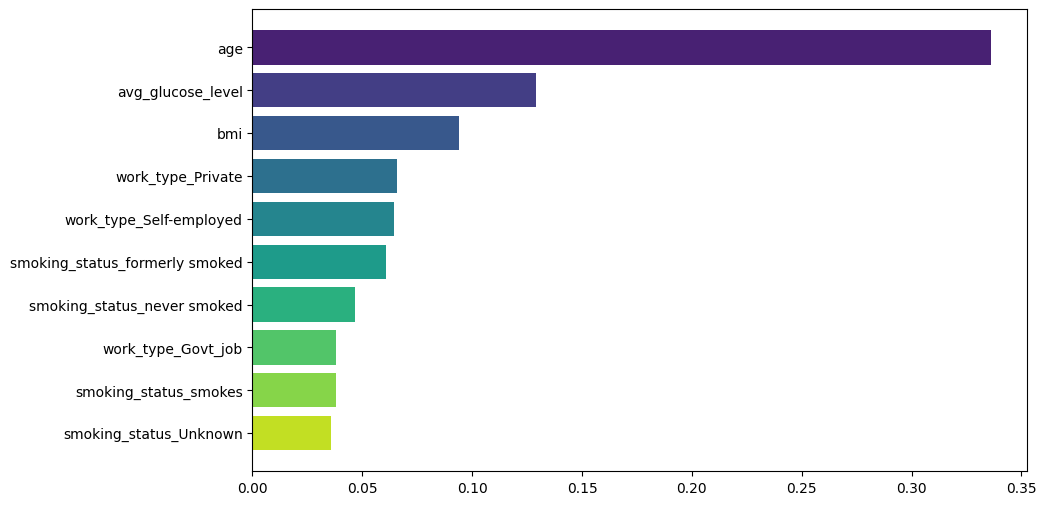

In [20]:
# =============================================================
# VISUALISASI 3: FEATURE IMPORTANCE
# =============================================================

importances = model_rf.feature_importances_
feature_names = X.columns
indices = np.argsort(importances)[::-1]

# Ambil Top 10 fitur paling berpengaruh
top_n = 10
top_indices = indices[:top_n]

plt.figure(figsize=(10, 6))
colors = sns.color_palette('viridis', top_n)
bars = plt.barh(feature_names[top_indices][::-1],
                importances[top_indices][::-1],
                color=colors[::-1])


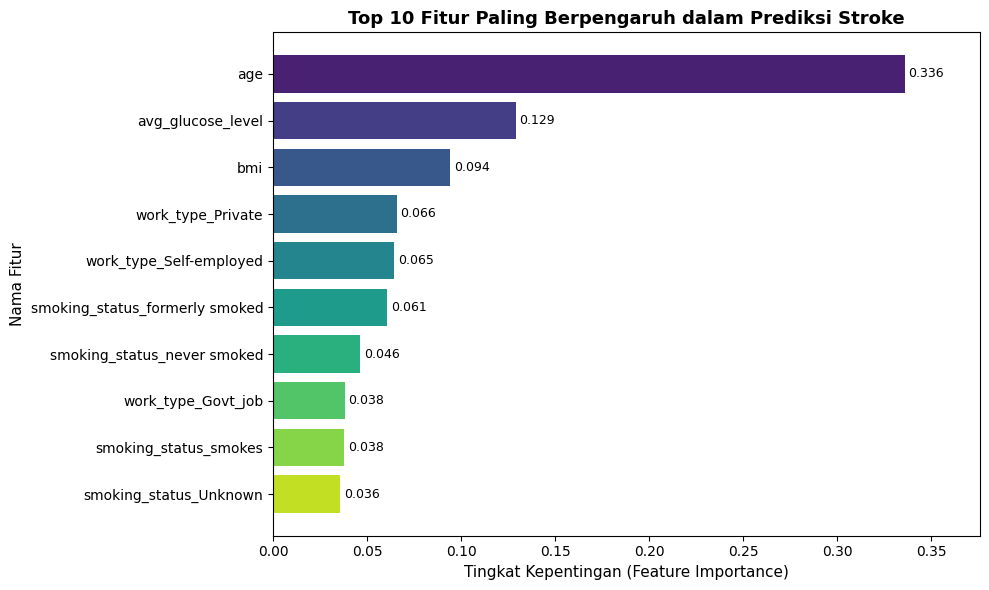

In [24]:
fig, ax = plt.subplots(figsize=(10, 6))
colors = sns.color_palette('viridis', top_n)
bars = ax.barh(feature_names[top_indices][::-1],
               importances[top_indices][::-1],
               color=colors[::-1])

for bar, imp in zip(bars, importances[top_indices][::-1]):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
            f'{imp:.3f}', va='center', fontsize=9)

ax.set_xlim(0, importances[top_indices].max() + 0.04)  # biar label ga kepotong
ax.set_title(f'Top {top_n} Fitur Paling Berpengaruh dalam Prediksi Stroke',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Tingkat Kepentingan (Feature Importance)', fontsize=11)
ax.set_ylabel('Nama Fitur', fontsize=11)
plt.tight_layout()
plt.show()

In [23]:
# =============================================================
# RINGKASAN AKHIR
# =============================================================

print("\n" + "="*55)
print(" RINGKASAN MODEL ".center(55, "="))
print("="*55)
print(f"  Algoritma        : Random Forest Classifier")
print(f"  Jumlah Pohon     : 100 estimators")
print(f"  Handling Imbal.  : SMOTE (Oversampling kelas minoritas)")
print(f"  Akurasi          : {akurasi*100:.2f}%")
print(f"  ROC-AUC Score    : {roc_auc:.4f}")
print(f"  Recall (Stroke)  : {cm[1][1]/(cm[1][0]+cm[1][1])*100:.2f}%")
print("="*55)



=================== RINGKASAN MODEL ===================
  Algoritma        : Random Forest Classifier
  Jumlah Pohon     : 100 estimators
  Handling Imbal.  : SMOTE (Oversampling kelas minoritas)
  Akurasi          : 93.25%
  ROC-AUC Score    : 0.7762
  Recall (Stroke)  : 2.00%


In [25]:
pip install streamlit joblib scikit-learn imbalanced-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 54.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 73.6 MB/s eta 0:00:00


In [34]:
# =====================================================================
# FIX TOTAL: BYPASS ERROR NAMA KOLOM DENGAN NUMPY ARRAY
# =====================================================================

# 1. Install library pendukung
!pip install streamlit pyngrok --quiet

import os
import pickle
import pandas as pd
from pyngrok import ngrok

# 2. Set Authtoken Ngrok milikmu
NGROK_AUTH_TOKEN = "3DvBZDYg2sqaiLUqD9nKnnDej1q_4uzaCreUP8E25455vDjJp"
ngrok.set_auth_token(NGROK_AUTH_TOKEN)

# 3. Simpan model dan daftar kolom asli dari notebook
try:
    with open('model_rf.pkl', 'wb') as f:
        pickle.dump(model_rf, f)

    with open('features_list.pkl', 'wb') as f:
        pickle.dump(list(X.columns), f)

    print("✅ BERHASIL: Model dan Susunan Fitur berhasil disimpan!")
except NameError:
    print("❌ ERROR: Jalankan ulang cell 'BAGIAN 4: TRAINING MODEL' milikmu dulu baru jalankan cell ini!")

# 4. Membuat file app.py yang mengabaikan nama kolom saat prediksi
streamlit_code = """
import streamlit as st
import pandas as pd
import numpy as np
import pickle

st.set_page_config(page_title="Prediksi Risiko Stroke", layout="centered", page_icon="🏥")

st.title("🏥 Aplikasi Prediksi Risiko Penyakit Stroke")
st.write("Aplikasi Interaktif Tugas Besar - Kelompok 8")
st.markdown("---")

@st.cache_resource
def load_resources():
    with open('model_rf.pkl', 'rb') as file:
        model = pickle.load(file)
    with open('features_list.pkl', 'rb') as file:
        features_list = pickle.load(file)
    return model, features_list

try:
    model, features_list = load_resources()
except FileNotFoundError:
    st.error("File model atau fitur tidak ditemukan! Pastikan cell di notebook sudah sukses dieksekusi.")

st.header("Form Input Data Medis Pasien")
col1, col2 = st.columns(2)

with col1:
    gender = st.selectbox("Jenis Kelamin", ["Male", "Female"])
    age = st.number_input("Usia (Tahun)", min_value=0, max_value=120, value=45)
    hypertension = st.selectbox("Memiliki Riwayat Hipertensi?", ["Tidak", "Ya"])
    heart_disease = st.selectbox("Memiliki Penyakit Jantung?", ["Tidak", "Ya"])
    ever_married = st.selectbox("Pernah Menikah?", ["No", "Yes"])
    residence = st.selectbox("Tipe Tempat Tinggal", ["Urban", "Rural"])

with col2:
    avg_glucose = st.number_input("Rata-Rata Kadar Glukosa (mg/dL)", min_value=0.0, value=100.0)
    bmi = st.number_input("Indeks Massa Tubuh / BMI", min_value=0.0, value=25.0)
    work_type = st.selectbox("Tipe Pekerjaan", ["Govt_job", "Never_worked", "Private", "Self-employed", "children"])
    smoking_status = st.selectbox("Status Merokok", ["Unknown", "formerly smoked", "never smoked", "smokes"])

if st.button("Analisis Risiko Stroke", type="primary"):
    gender_encoded = 1 if gender == "Male" else 0
    married_encoded = 1 if ever_married == "Yes" else 0
    residence_encoded = 1 if residence == "Urban" else 0
    hypertension_encoded = 1 if hypertension == "Ya" else 0
    heart_disease_encoded = 1 if heart_disease == "Ya" else 0

    # Kumpulkan inputan user ke dalam dictionary
    data_input = {
        'gender': gender_encoded,
        'age': age,
        'hypertension': hypertension_encoded,
        'heart_disease': heart_disease_encoded,
        'ever_married': married_encoded,
        'Residence_type': residence_encoded,
        'avg_glucose_level': avg_glucose,
        'bmi': bmi,

        'work_type_Govt_job': int(work_type == "Govt_job"),
        'work_type_Never_worked': int(work_type == "Never_worked"),
        'work_type_Private': int(work_type == "Private"),
        'work_type_Self-employed': int(work_type == "Self-employed"),
        'work_type_children': int(work_type == "children"),

        'smoking_status_Unknown': int(smoking_status == "Unknown"),
        'smoking_status_formerly smoked': int(smoking_status == "formerly smoked"),
        'smoking_status_never smoked': int(smoking_status == "never smoked"),
        'smoking_status_smokes': int(smoking_status == "smokes")
    }

    # Ubah jadi DataFrame
    df_input = pd.DataFrame([data_input])

    # Urutkan kolom sesuai features_list asli dari notebook
    df_input = df_input[features_list]

    # Trik Jitu: Ambil nilai value-nya saja menjadi Numpy Array (.values)
    # agar scikit-learn tidak memprotes nama/order string dari kolom DataFrame.
    input_array = df_input.values

    # Jalankan prediksi menggunakan Numpy Array
    prediction = model.predict(input_array)
    proba = model.predict_proba(input_array)[0][1] * 100

    st.markdown("---")
    st.subheader("Hasil Analisis Klinis:")
    if prediction[0] == 1:
        st.error(f"⚠️ **RISIKO TINGGI:** Pasien terindikasi memiliki risiko penyakit stroke.")
    else:
        st.success(f"✅ **RISIKO RENDAH:** Pasien terindikasi aman dari risiko penyakit stroke.")
    st.write(f"Probabilitas kecenderungan model: **{proba:.2f}%**")
"""

with open("app.py", "w") as f:
    f.write(streamlit_code)

print("✅ File app.py berhasil diperbarui dengan fitur bypass array!")

# 5. Restart server Streamlit
os.system("pkill streamlit")
os.system("streamlit run app.py --server.port 8501 &")

# 6. Hubungkan kembali ke terowongan Ngrok publik
try:
    ngrok.disconnect(ngrok.connect(8501).public_url)
except:
    pass

public_url = ngrok.connect(8501, proto="http")
print("\n" + "="*60)
print(f"🚀 LINK FIX SUDAH SIAP DIPAKAI ASISTENSI:")
print(f"🔗 Klik Link Ini: {public_url.public_url}")
print("="*60)

✅ BERHASIL: Model dan Susunan Fitur berhasil disimpan!
✅ File app.py berhasil diperbarui dengan fitur bypass array!



🚀 LINK FIX SUDAH SIAP DIPAKAI ASISTENSI:
🔗 Klik Link Ini: https://coconut-seminar-overfull.ngrok-free.dev
